# Estimativa de Peso de Bovinos por Medidas Morfométricas

**Objetivo:** Comparar modelos de machine learning para prever o peso vivo de vacas Hereford a partir de medidas corporais simples, sem necessidade de balança industrial.

**Dataset:** Hereford_cows - Ruchay et al. (2022) | 1.523 vacas | 11 medidas corporais + idade

**Por que isso é relevante para a região da Campanha Gaucha?**  
A Campanha Gaúcha tem uma das maiores concentrações de pecuária de corte do país, com Hereford e Braford dominando os campos nativos do Pampa. Monitorar ganho de peso é parte do dia a dia do produtor, mas balança de precisão ainda é realidade de poucos. Com medidas tiradas no manejo rotineiro e um modelo treinado, qualquer propriedade consegue estimar o peso dos animais sem custo extra.

## 0. Instalação de Dependências

In [1]:
!pip install shap xgboost --quiet
print('Dependências prontas')

Dependências prontas


## 1. Imports e Configuração

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from scipy import stats
from xgboost import XGBRegressor
import shap
import pickle, os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
SEED = 42
np.random.seed(SEED)
print('Imports OK')

Imports OK


## 2. Carregamento e Padronização

In [3]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/jota6k/projeto_peso_bovinos/main/data/Hereford_cows.csv',
    encoding='latin-1',
    sep=';'
)

df = df.drop(columns=['n.', 'identificator'])

df = df.rename(columns={
    'Age years':              'idade_anos',
    'Body weight':            'peso_kg',
    'withers height':         'altura_cernelha',
    'hip height':             'altura_garupa',
    'chest depth':            'profundidade_peito',
    'chest width':            'largura_peito',
    'heart girth':            'perimetro_toracico',
    'ilium width':            'largura_iliaca',
    'sciatic tubercle width': 'largura_isquiatica',
    'oblique body length':    'comp_obliquo_corpo',
    'oblique rear length':    'comp_obliquo_traseiro',
    'metacarpus girth':       'perimetro_metacarpo',
    'backside half-girth':    'meia_circ_traseira',
})

FEATURES = [
    'altura_cernelha', 'altura_garupa', 'profundidade_peito',
    'largura_peito', 'perimetro_toracico', 'largura_iliaca',
    'largura_isquiatica', 'comp_obliquo_corpo', 'comp_obliquo_traseiro',
    'perimetro_metacarpo', 'meia_circ_traseira', 'idade_anos'
]
TARGET = 'peso_kg'

NOMES_PT = {
    'altura_cernelha':       'Altura Cernelha (cm)',
    'altura_garupa':         'Altura Garupa (cm)',
    'profundidade_peito':    'Prof. Peito (cm)',
    'largura_peito':         'Larg. Peito (cm)',
    'perimetro_toracico':    'Perím. Torácico (cm)',
    'largura_iliaca':        'Larg. Ilíaca (cm)',
    'largura_isquiatica':    'Larg. Isquiática (cm)',
    'comp_obliquo_corpo':    'Comp. Oblíquo Corpo (cm)',
    'comp_obliquo_traseiro': 'Comp. Oblíquo Traseiro (cm)',
    'perimetro_metacarpo':   'Perím. Metacarpo (cm)',
    'meia_circ_traseira':    'Meia Circ. Traseira (cm)',
    'idade_anos':            'Idade (anos)',
    'area_corporal':   'Área Corporal (cm²)',
    'ratio_altura':    'Ratio Cernelha/Garupa',
    'volume_estimado': 'Volume Estimado (cm³)',
}

# Remove único valor nulo (perimetro_metacarpo)
df = df.dropna()

print(f'Dataset: {df.shape[0]} animais, {df.shape[1]} variáveis')
print(f'Features: {len(FEATURES)} | Target: {TARGET}')
print()
print(df[FEATURES + [TARGET]].describe().round(2))

Dataset: 1522 animais, 13 variáveis
Features: 12 | Target: peso_kg

       altura_cernelha  altura_garupa  profundidade_peito  largura_peito  \
count          1522.00        1522.00             1522.00        1522.00   
mean            126.73         130.00               66.03          46.74   
std               3.80           4.05                6.64           6.53   
min             112.00         116.00               12.00          10.00   
25%             125.00         128.00               62.00          42.00   
50%             127.00         130.00               67.00          45.00   
75%             129.00         132.00               70.00          50.00   
max             141.00         147.00               88.00          72.00   

       perimetro_toracico  largura_iliaca  largura_isquiatica  \
count             1522.00         1522.00             1522.00   
mean               189.18           51.63               26.29   
std                 12.62            5.87           

## 3. Análise Exploratória (EDA)

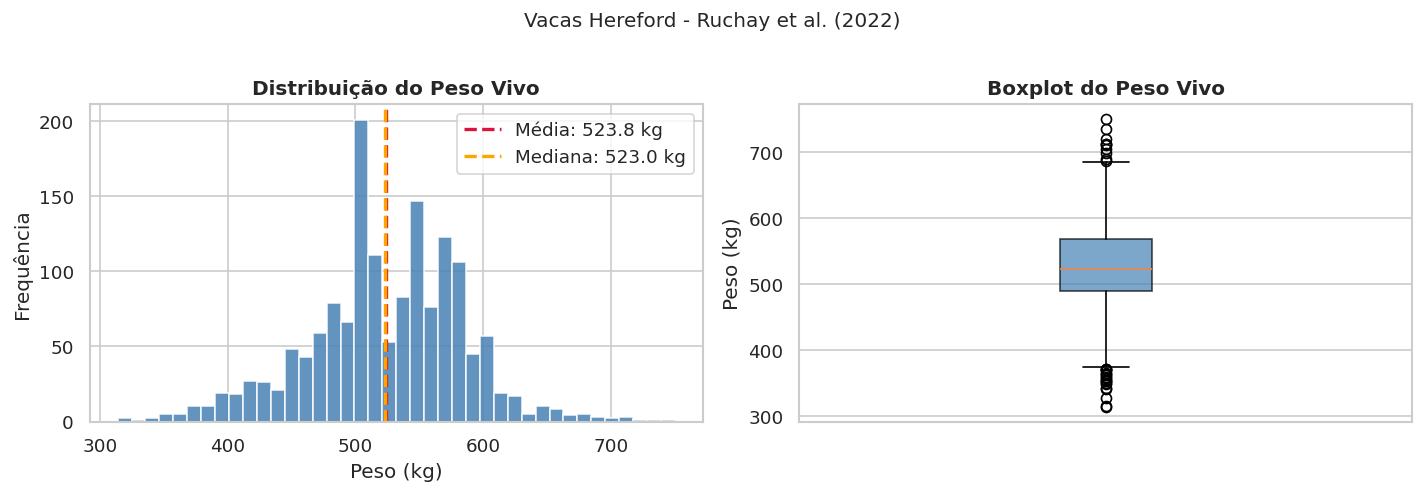

Assimetria: -0.204 | Curtose: 0.516


In [4]:
# Distribuição do peso
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[TARGET], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df[TARGET].mean(), color='crimson', linestyle='--', linewidth=2,
                label=f'Média: {df[TARGET].mean():.1f} kg')
axes[0].axvline(df[TARGET].median(), color='orange', linestyle='--', linewidth=2,
                label=f'Mediana: {df[TARGET].median():.1f} kg')
axes[0].set_title('Distribuição do Peso Vivo', fontweight='bold')
axes[0].set_xlabel('Peso (kg)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

axes[1].boxplot(df[TARGET], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot do Peso Vivo', fontweight='bold')
axes[1].set_ylabel('Peso (kg)')
axes[1].set_xticks([])

plt.suptitle('Vacas Hereford - Ruchay et al. (2022)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()
print(f'Assimetria: {df[TARGET].skew():.3f} | Curtose: {df[TARGET].kurtosis():.3f}')

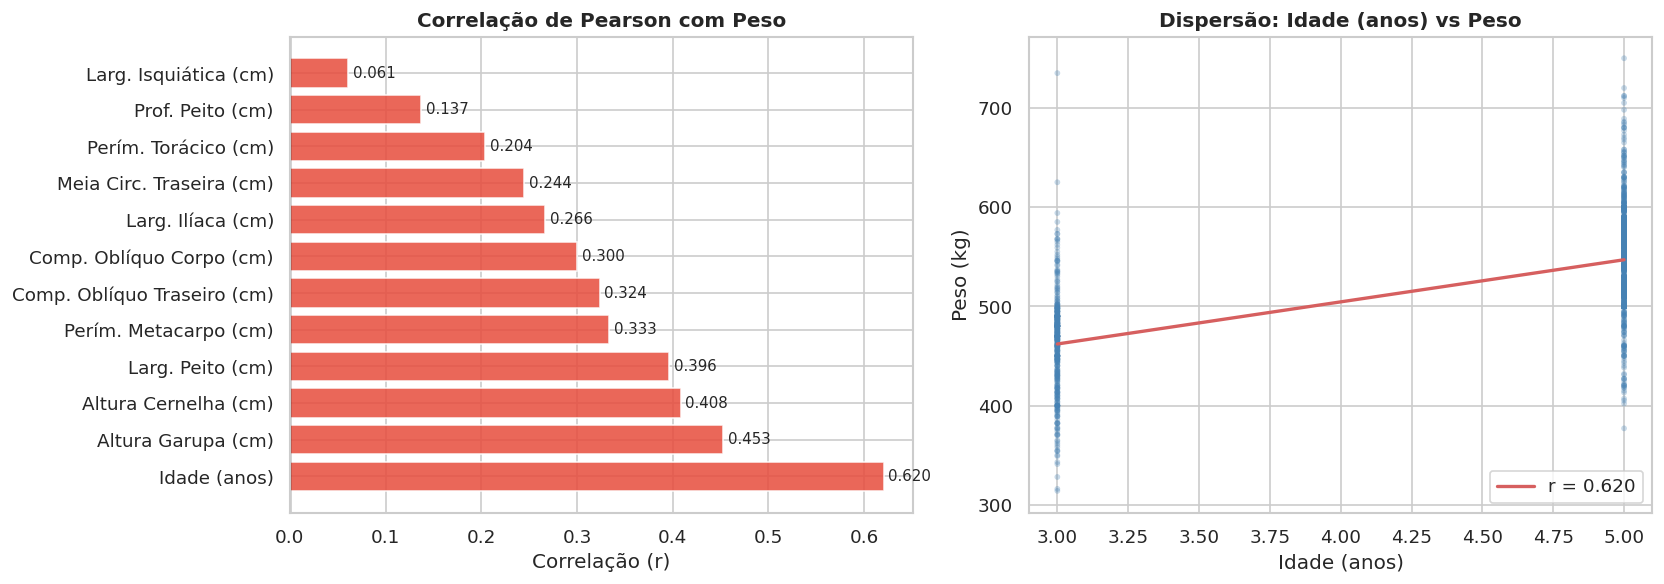

In [5]:
# Correlação das features com o peso
corr_com_peso = df[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores = ['#e74c3c' if v > 0 else '#3498db' for v in corr_com_peso]
axes[0].barh([NOMES_PT.get(f, f) for f in corr_com_peso.index],
             corr_com_peso.values, color=cores, alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Correlação de Pearson com Peso', fontweight='bold')
axes[0].set_xlabel('Correlação (r)')
for i, v in enumerate(corr_com_peso.values):
    axes[0].text(v + 0.005 if v > 0 else v - 0.005, i,
                 f'{v:.3f}', va='center', ha='left' if v > 0 else 'right', fontsize=9)

top_feat = corr_com_peso.index[0]
axes[1].scatter(df[top_feat], df[TARGET], alpha=0.3, s=12, color='steelblue', edgecolors='none')
z = np.polyfit(df[top_feat], df[TARGET], 1)
x_line = np.linspace(df[top_feat].min(), df[top_feat].max(), 200)
axes[1].plot(x_line, np.poly1d(z)(x_line), 'r-', linewidth=2,
             label=f'r = {corr_com_peso[top_feat]:.3f}')
axes[1].set_xlabel(NOMES_PT.get(top_feat, top_feat))
axes[1].set_ylabel('Peso (kg)')
axes[1].set_title(f'Dispersão: {NOMES_PT.get(top_feat, top_feat)} vs Peso', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()

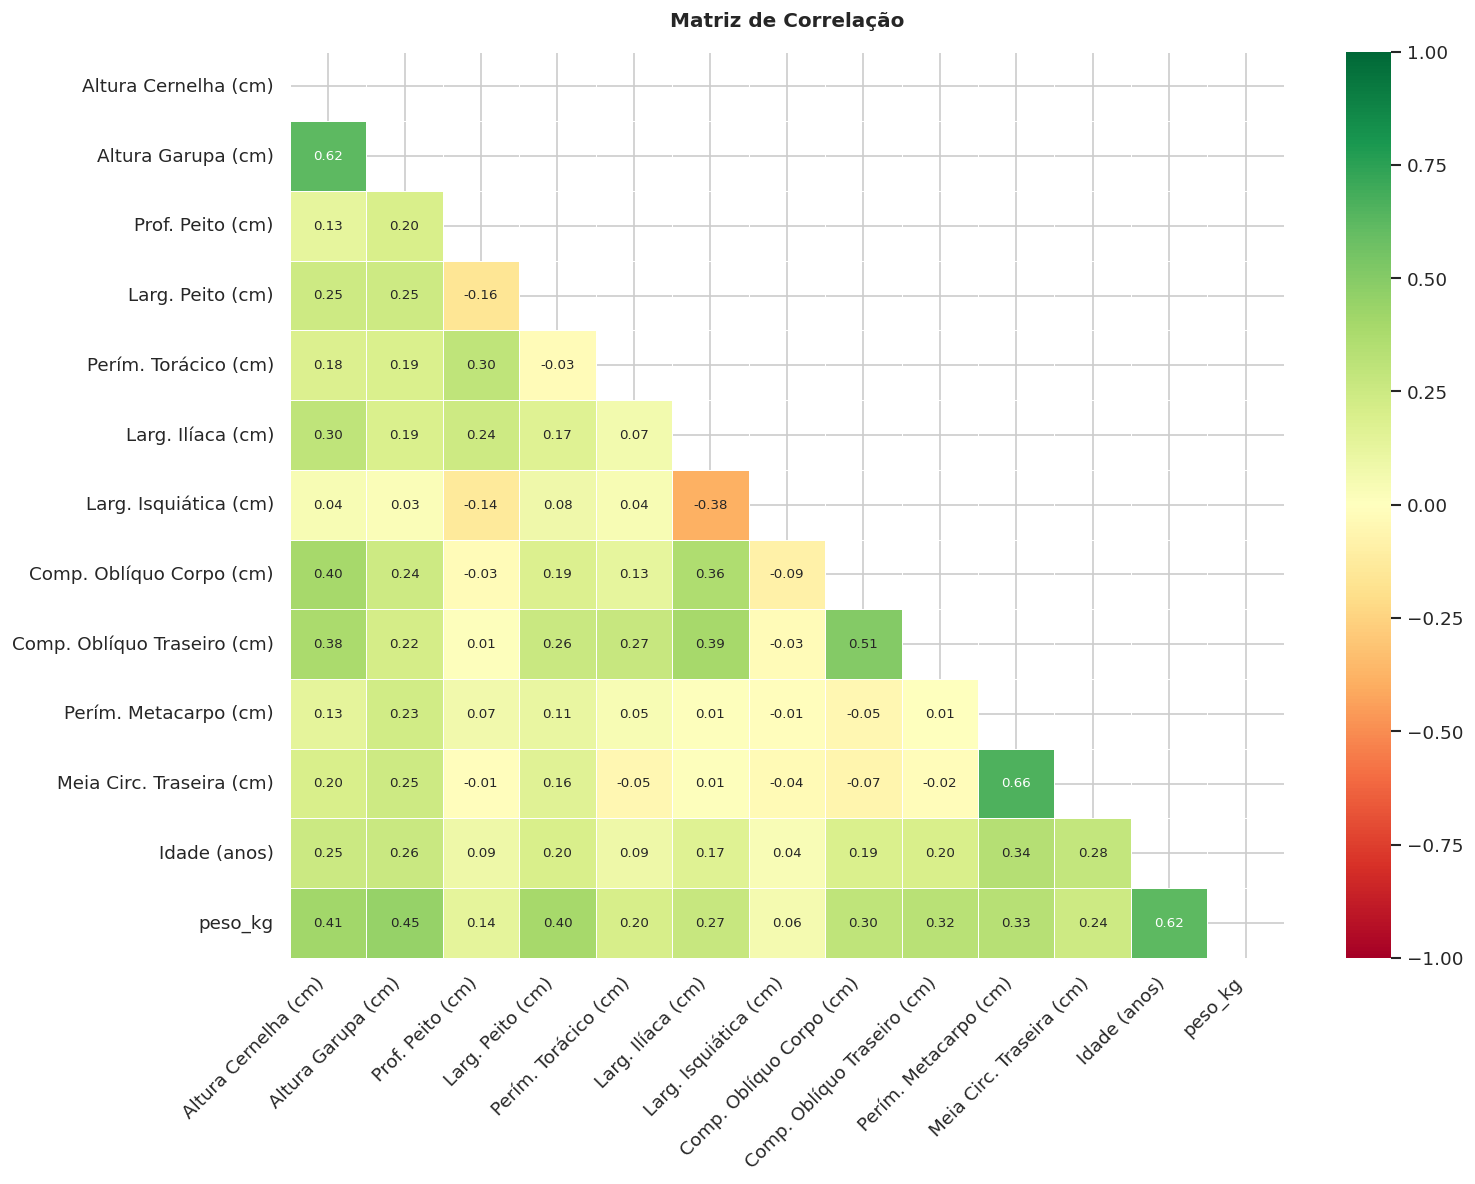

In [6]:
# Heatmap de correlação
fig, ax = plt.subplots(figsize=(13, 10))
cols = FEATURES + [TARGET]
labels = [NOMES_PT.get(c, c) for c in cols]
corr_matrix = df[cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Matriz de Correlação', fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Pré-processamento

In [7]:
# Feature engineering
df['area_corporal']   = df['comp_obliquo_corpo'] * df['perimetro_toracico']
df['ratio_altura']    = df['altura_cernelha'] / df['altura_garupa']
df['volume_estimado'] = df['perimetro_toracico']**2 * df['comp_obliquo_corpo']
FEATURES += ['area_corporal', 'ratio_altura', 'volume_estimado']

X = df[FEATURES].copy()
y = df[TARGET].copy()

# Remove outliers extremos (1% e 99%)
mask_outlier = (y >= y.quantile(0.01)) & (y <= y.quantile(0.99))
X = X[mask_outlier].reset_index(drop=True)
y = y[mask_outlier].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

print(f'Treino: {len(X_train)} | Teste: {len(X_test)}')
print(f'Peso médio treino: {y_train.mean():.1f} kg | teste: {y_test.mean():.1f} kg')

Treino: 1192 | Teste: 299
Peso médio treino: 524.7 kg | teste: 519.3 kg


In [8]:
# Escalonamento global (Disponível para tuning, SHAP e simulador)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Dados escalonados prontos')

Dados escalonados prontos
